In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates
from AnalysisTools.DBManager import MarketDB

/root/miniconda3/envs/finance/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [35]:
symbols = MarketDB("KRX").get_comp_info()
print(len(symbols))

2480


In [37]:
original_samples = dict()
ref = MarketDB("ETF").get_daily_price("KODEX 200", "2017-01-01")
for symbol in symbols.values():
    sample = MarketDB("KRX").get_daily_price(symbol, "2017-01-01")
    if len(sample.index) < 220:
        continue
    
    # preprocess
    sample['noise'] = 1. - abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['return'] = 1. + sample['close'].pct_change()
    sample['reward'] = 1. + sample['close'].pct_change()
    sample['total_reward'] = sample['reward'].cumprod()
    sample['log_reward'] = np.log(sample['reward'])
    sample.dropna(inplace=True)
    
    original_samples[symbol] = sample.copy()
    del sample

/tmp/ipykernel_30877/2727741307.py:15: RuntimeWarning: invalid value encountered in double_scalars
  sample.loc[idx, 'value'] = log_rtn + gamma*(sample.shift(1).loc[idx, 'value'])
/root/miniconda3/envs/finance/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 46041 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/envs/finance/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 54868 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/envs/finance/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 50557 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/envs/finance/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 54408 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/root/miniconda3/envs/finance/lib/python3.9/site-packages/ma

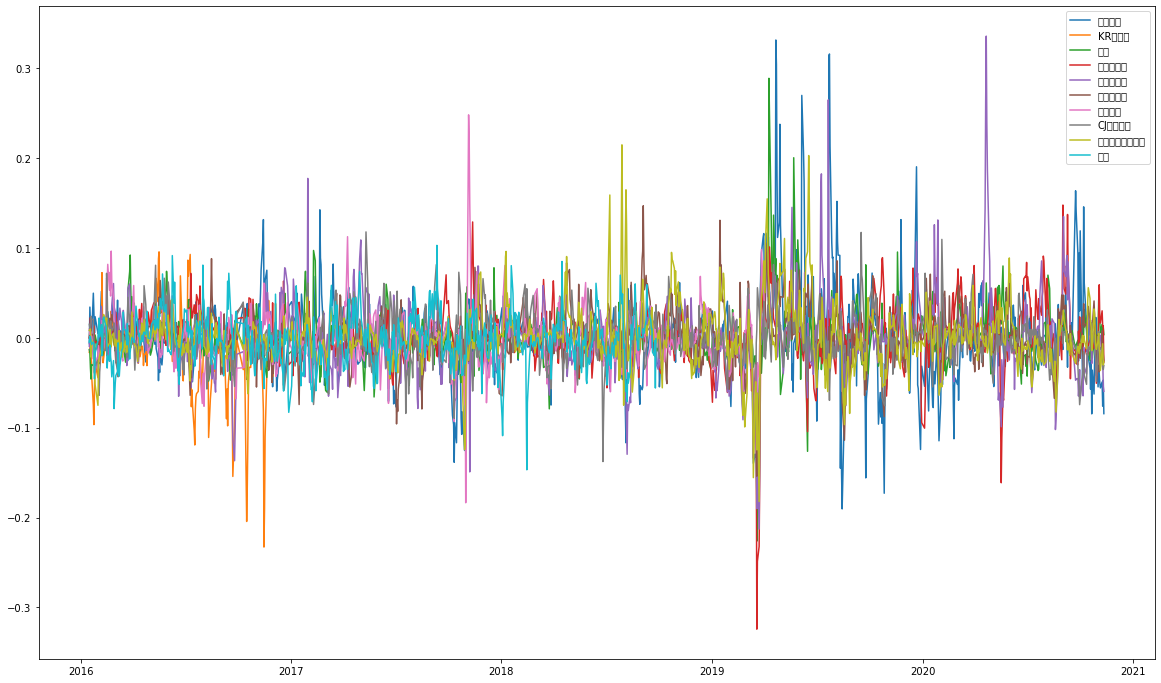

In [38]:
samples = dict()
#gamma = 0.9
for symbol in original_samples.keys():
    sample = original_samples[symbol].copy()
    sample['value'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value'] = sample.loc[idx, 'log_reward']
            continue
        
        # log_rtn = sample.loc[idx, 'log_reward'] if sample.loc[idx, 'momentum'] > 0. else 0.
        log_rtn = sample.loc[idx, 'log_reward']
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value'] = log_rtn + gamma*(sample.shift(1).loc[idx, 'value'])
    samples[symbol] = sample

plt.figure(figsize=(20, 12))
for symbol in list(samples.keys())[:10]:
    plt.plot(samples[symbol].index, samples[symbol].value, label=symbol)
plt.legend(loc='best')
plt.show()

In [40]:
book = samples["삼성전자"][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value'] = 0.

for idx in ref.index:
    if idx == ref.index[0]:
        continue
    
    # select 20 highest coins
    volumes = dict()
    for symbol in samples.keys(): 
        try:
            volumes[symbol] = samples[symbol].loc[idx, 'close'] * samples[symbol].loc[idx, 'volume']
        except:
            continue
    top20v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:50])
    
    # make dictionary for the values
    values = dict()
    for symbol in top20v.keys():
        try:
            values[symbol] = samples[symbol].loc[idx, 'value']
        except:
            pass
        
    if len(values) == 0:
        continue
    
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:20])
    value = np.mean(list(res.values()))
    
    #momentums = list()
    #for coin in res.keys():
    #    momentums.append(samples[coin].shift(1).loc[idx, 'momentum'])

    reward = 0.
    for i, symbol in enumerate(res.keys()):
        ratio = 1./len(res)
        #if samples[coin].loc[idx, 'momentum'] < 0. or samples[coin].loc[idx, 'value'] < samples["BTCUSDT"].loc[idx, 'value']:
        if samples[symbol].loc[idx, 'momentum'] < 0.:
            reward += ratio
        else:
            reward += ratio*(samples[symbol].shift(-1).loc[idx, 'return']-0.001)
        
    book.loc[idx, 'reward'] = reward
    book.loc[idx, 'value'] = value
book.dropna(inplace=True)

==== value trading ====
Accumulated Returns: -82.36 %
CAGR: -44.7 %
MDD: -86.92 %
VOL: 48.425 %
Sharpe: 75276.19 %


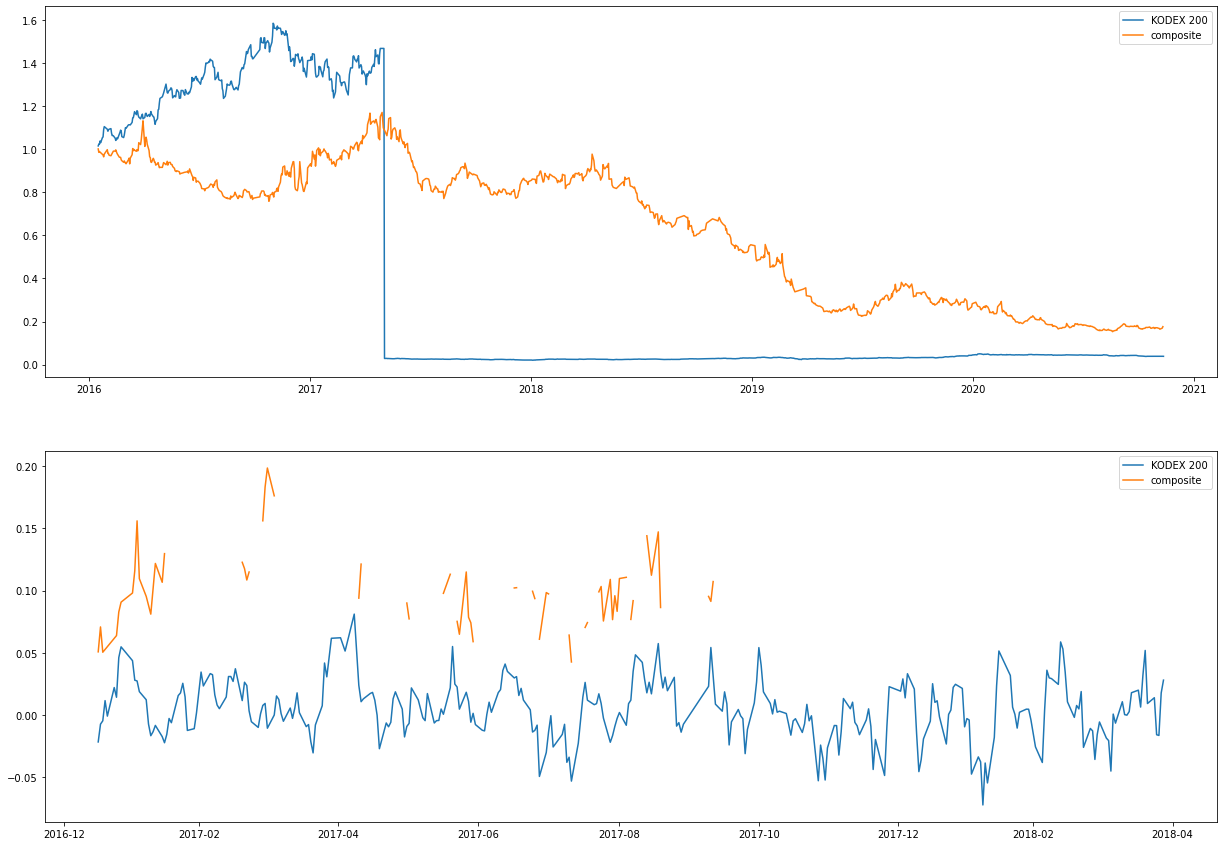

In [42]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)                                     # 주가의 변동폭은 시간의 제곱근에 비례
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))       # 연율화된 sharpe ratio # unacceptable

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
#plt.yscale('log')
#for coin in samples.keys():
#    plt.plot(samples[coin].index, samples[coin].total_reward, label=coin)
plt.plot(samples['삼성전자'].index, samples['삼성전자'].total_reward, label="KODEX 200")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['삼성전자'].index, samples['삼성전자'].value, label="KODEX 200")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()